# Task 5: Panoramic Image using SIFT

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

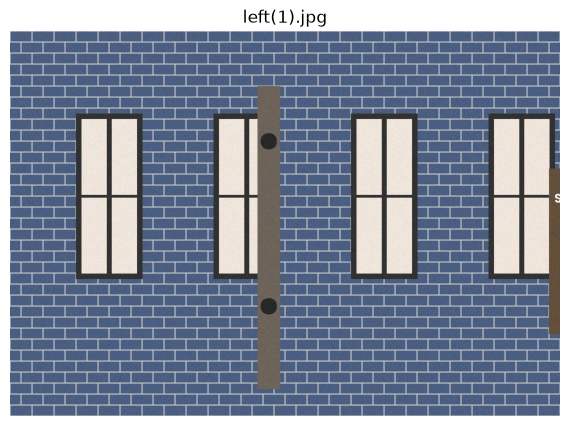

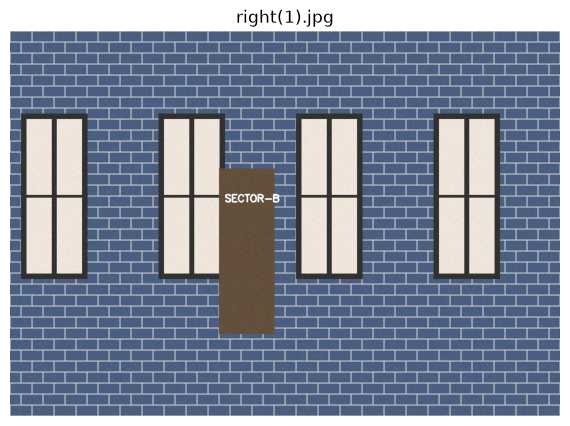

In [6]:
# ============================================================
# Load Panorama Images
# ============================================================

# List images in left-to-right capture order
IMAGE_PATHS = [
    'left(1).jpg',
    'right(1).jpg'
]


# ============================================================
# Load Images
# ============================================================

images = [
    cv.imread(path)
    for path in IMAGE_PATHS
]


# ============================================================
# Validate Images
# ============================================================

for path, image in zip(IMAGE_PATHS, images):

    if image is None:
        raise FileNotFoundError(
            f"Image not found: {path}"
        )


# ============================================================
# Display Input Images
# ============================================================

for path, image in zip(
    IMAGE_PATHS,
    images
):

    show(
        image,
        path,
        size=(8, 5)
    )


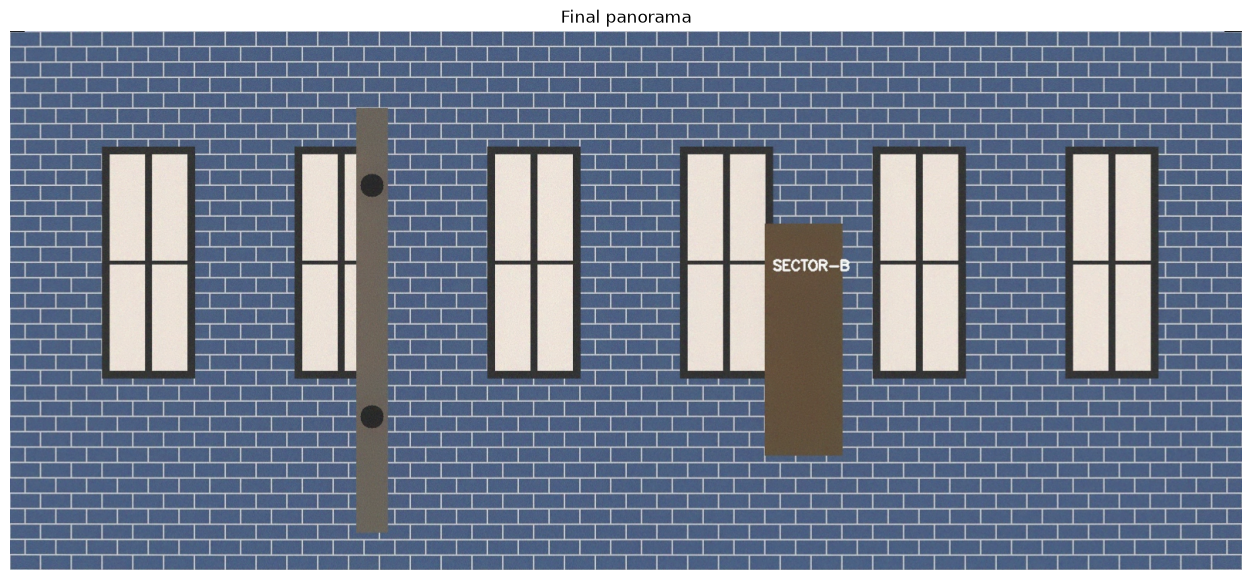

Saved task5_panorama.jpg
Panorama shape: (699, 1598, 3)


In [7]:
# ============================================================
# Panorama Stitching
# ============================================================

# OpenCV's panorama stitcher internally performs:
# - Feature extraction
# - Feature matching
# - Camera estimation
# - Image warping
# - Seam estimation
# - Exposure compensation

stitcher = cv.Stitcher_create(
    cv.Stitcher_PANORAMA
)


# ============================================================
# Stitch Images
# ============================================================

status, pano = stitcher.stitch(
    images
)

if status != cv.Stitcher_OK:

    raise RuntimeError(
        f"Stitching failed with status {status}. "
        "Ensure the images have approximately 30-50% "
        "overlap and contain enough textured content."
    )


# ============================================================
# Remove Black Borders
# ============================================================

gray_pano = cv.cvtColor(
    pano,
    cv.COLOR_BGR2GRAY
)

# Create mask of non-black pixels
_, mask = cv.threshold(
    gray_pano,
    1,
    255,
    cv.THRESH_BINARY
)

# Find the bounding rectangle of valid panorama pixels
nonzero = cv.findNonZero(
    mask
)

if nonzero is None:

    raise RuntimeError(
        "Panorama contains no valid image pixels."
    )

x, y, w, h = cv.boundingRect(
    nonzero
)


# ============================================================
# Crop Panorama
# ============================================================

cropped = pano[
    y:y + h,
    x:x + w
]


# ============================================================
# Display and Save
# ============================================================

show(
    cropped,
    'Final panorama',
    size=(18, 7)
)

cv.imwrite(
    'task5_panorama.jpg',
    cropped
)

print(
    'Saved task5_panorama.jpg'
)

print(
    'Panorama shape:',
    cropped.shape
)


## Capture requirements
Use roughly **30 to 50 percent overlap**, rotate the camera about the same optical center, and lock exposure where possible. Moving objects, textureless walls, large parallax, or images supplied in the wrong order can cause matching or seam failures.